# Capítulo 19 — Ajuste de hiperparámetros

En el capítulo anterior usamos validación cruzada para obtener evaluaciones más estables. Ahora aprovecharemos esa herramienta para comparar distintas configuraciones de un mismo modelo.

Trabajaremos con **KNN** porque ya conocemos el efecto de la cantidad de vecinos y la necesidad de escalar las variables. Comenzaremos con una búsqueda manual y luego automatizaremos el proceso con `GridSearchCV` y `RandomizedSearchCV`.

Durante todo el recorrido mantendremos separado un conjunto de prueba final. La selección de hiperparámetros se hará únicamente con los datos de desarrollo.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- distinguir parámetros aprendidos de hiperparámetros definidos antes de entrenar;
- relacionar los hiperparámetros con la complejidad y la generalización;
- realizar una búsqueda manual mediante validación cruzada;
- ajustar un pipeline completo con `GridSearchCV`;
- interpretar `best_params_`, `best_score_` y `cv_results_`;
- usar `RandomizedSearchCV` para limitar la cantidad de combinaciones;
- calcular el costo de una búsqueda en cantidad de entrenamientos;
- reconocer que la mejor configuración depende de la métrica;
- reservar el test para una única evaluación final.


## 1. Importar las herramientas

Usaremos Pandas para organizar los resultados, Matplotlib para visualizarlos y `scikit-learn` para preparar el pipeline, construir los folds y realizar las búsquedas.


In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.dpi"] = 110


## 2. Preparar los datos y reservar el test final

Continuaremos con el dataset **Breast Cancer Wisconsin**, utilizado en los cuadernos anteriores. Cada fila contiene mediciones obtenidas a partir de imágenes digitalizadas de muestras celulares.

Mantendremos la misma convención:

- `0`: caso benigno;
- `1`: caso maligno.

La clase positiva representa el caso que queremos detectar.

> Este dataset se utiliza exclusivamente con fines educativos. Los resultados del cuaderno no constituyen una herramienta médica ni deben usarse para tomar decisiones clínicas.


In [2]:
datos_medicos = load_breast_cancer(as_frame=True)

X = datos_medicos.data

# En el dataset original, 0 significa maligno y 1 benigno.
# Invertimos las etiquetas para conservar la convención de la serie.
y = 1 - datos_medicos.target
y.name = "caso_maligno"

pd.DataFrame({
    "filas": [len(X)],
    "variables": [X.shape[1]],
    "casos_benignos": [(y == 0).sum()],
    "casos_malignos": [(y == 1).sum()],
})


,filas,variables,casos_benignos,casos_malignos
0,569,30,357,212


Antes de comparar configuraciones, separaremos el 20% de los datos como **prueba final**. Todo el ajuste se realizará sobre el conjunto de desarrollo.


In [3]:
X_desarrollo, X_test_final, y_desarrollo, y_test_final = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=19,
    stratify=y,
)

pd.DataFrame({
    "conjunto": ["Desarrollo", "Prueba final"],
    "filas": [len(X_desarrollo), len(X_test_final)],
    "proporcion_malignos": [
        y_desarrollo.mean(),
        y_test_final.mean(),
    ],
}).round(3)


,conjunto,filas,proporcion_malignos
0,Desarrollo,455,0.374
1,Prueba final,114,0.368


Hasta la sección final no consultaremos `X_test_final` ni `y_test_final`. Si midiéramos cada configuración sobre esos datos y eligiéramos la ganadora, el test dejaría de ser una evaluación independiente.


## 3. Parámetros e hiperparámetros

Los **hiperparámetros** se definen antes del entrenamiento. En KNN, `n_neighbors`, `weights` y `p` modifican la forma de clasificar.

Los **parámetros o estados aprendidos** aparecen después de ajustar el pipeline. Por ejemplo, `StandardScaler` aprende la media y la escala de cada variable a partir de los datos de entrenamiento.


In [4]:
pipeline_demostracion = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform",
        p=2,
    )),
])

pipeline_demostracion.fit(X_desarrollo, y_desarrollo)

pd.DataFrame({
    "ejemplo": [
        "modelo__n_neighbors",
        "modelo__weights",
        "modelo__p",
        "escala.mean_[0]",
        "escala.scale_[0]",
    ],
    "valor": [
        pipeline_demostracion.get_params()["modelo__n_neighbors"],
        pipeline_demostracion.get_params()["modelo__weights"],
        pipeline_demostracion.get_params()["modelo__p"],
        round(pipeline_demostracion.named_steps["escala"].mean_[0], 4),
        round(pipeline_demostracion.named_steps["escala"].scale_[0], 4),
    ],
    "tipo": [
        "Hiperparámetro",
        "Hiperparámetro",
        "Hiperparámetro",
        "Aprendido al ajustar",
        "Aprendido al ajustar",
    ],
})


,ejemplo,valor,tipo
0,modelo__n_neighbors,5,Hiperparámetro
1,modelo__weights,uniform,Hiperparámetro
2,modelo__p,2,Hiperparámetro
3,escala.mean_[0],14.152,Aprendido al ajustar
4,escala.scale_[0],3.5994,Aprendido al ajustar


El valor de `k` no se deduce automáticamente durante `fit()`: nosotros lo fijamos. En cambio, el escalador calcula sus estadísticas a partir de los datos que recibe.

Esta diferencia también explica por qué debemos evaluar el **pipeline completo**. En cada fold, el escalado tiene que aprenderse únicamente con la porción de entrenamiento correspondiente.


## 4. Realizar una búsqueda manual

Comenzaremos probando distintos valores de `k`. Todos los modelos usarán el mismo pipeline, los mismos cinco folds estratificados y F1-score como métrica.

Al conservar las mismas divisiones, las diferencias observadas se deben a la configuración y no a un cambio accidental de los folds.


In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

valores_k = [1, 3, 5, 7, 9, 11, 15, 21, 31]
resultados_manuales = []

for k in valores_k:
    pipeline = Pipeline(steps=[
        ("escala", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=k)),
    ])

    scores = cross_val_score(
        pipeline,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring="f1",
    )

    resultados_manuales.append({
        "k": k,
        "F1_promedio": scores.mean(),
        "desviacion_estandar": scores.std(),
        "F1_minimo": scores.min(),
        "F1_maximo": scores.max(),
    })

resultados_manuales = pd.DataFrame(resultados_manuales)


In [6]:
resultados_manuales.round(4)


,k,F1_promedio,desviacion_estandar,F1_minimo,F1_maximo
0,1,0.9403,0.0259,0.8986,0.9706
1,3,0.9481,0.0392,0.8788,0.9851
2,5,0.9446,0.0454,0.8615,0.9851
3,7,0.9514,0.0376,0.8788,0.9851
4,9,0.9516,0.0303,0.8955,0.9851
5,11,0.9483,0.0308,0.8955,0.9851
6,15,0.9329,0.0342,0.8657,0.9538
7,21,0.9365,0.0367,0.8657,0.9697
8,31,0.9355,0.0322,0.8750,0.9697


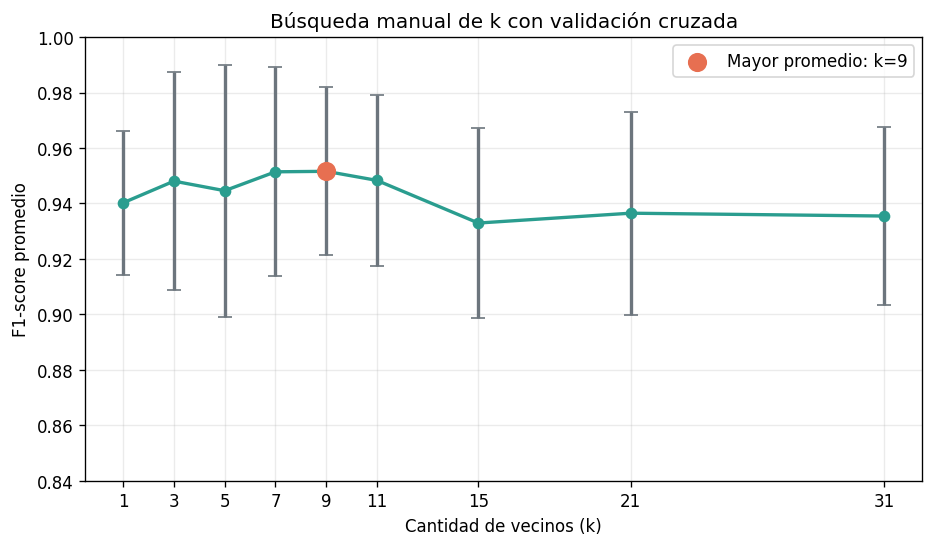

In [7]:
mejor_manual = resultados_manuales.loc[
    resultados_manuales["F1_promedio"].idxmax()
]

plt.figure(figsize=(9, 4.8))
plt.errorbar(
    resultados_manuales["k"],
    resultados_manuales["F1_promedio"],
    yerr=resultados_manuales["desviacion_estandar"],
    fmt="o-",
    color="#2A9D8F",
    ecolor="#6C757D",
    capsize=4,
    linewidth=2,
)
plt.scatter(
    mejor_manual["k"],
    mejor_manual["F1_promedio"],
    s=110,
    color="#E76F51",
    zorder=3,
    label=f"Mayor promedio: k={int(mejor_manual['k'])}",
)
plt.xlabel("Cantidad de vecinos (k)")
plt.ylabel("F1-score promedio")
plt.title("Búsqueda manual de k con validación cruzada")
plt.xticks(valores_k)
plt.ylim(0.84, 1.00)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


El mayor F1 promedio aparece con `k = 9`, pero varios valores cercanos producen resultados parecidos. Las barras representan la desviación estándar entre folds: el promedio no debe interpretarse sin observar también la variabilidad.

La búsqueda manual resulta transparente y útil para comprender el efecto de un hiperparámetro. Sin embargo, se vuelve incómoda cuando queremos combinar varias opciones.


## 5. Nombrar hiperparámetros dentro de un pipeline

Construiremos un pipeline con dos pasos:

1. `escala`: estandariza las variables;
2. `modelo`: aplica KNN.

Para referirnos a un hiperparámetro de un paso, usamos:

```text
nombre_del_paso__nombre_del_hiperparámetro
```

El doble guion bajo es parte de la sintaxis de `scikit-learn`.


In [8]:
pipeline_busqueda = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", KNeighborsClassifier()),
])

parametros_del_modelo = {
    nombre: valor
    for nombre, valor in pipeline_busqueda.get_params().items()
    if nombre in {
        "modelo__n_neighbors",
        "modelo__weights",
        "modelo__p",
    }
}

pd.Series(parametros_del_modelo, name="valor_actual")


modelo__n_neighbors          5
modelo__p                    2
modelo__weights        uniform
Name: valor_actual, dtype: object


Por ejemplo, `modelo__n_neighbors` indica que queremos modificar `n_neighbors` dentro del paso llamado `modelo`. Esta forma permite ajustar el pipeline sin separar el preprocesamiento de la validación.


## 6. Buscar todas las combinaciones con GridSearchCV

Ampliaremos la búsqueda combinando siete valores de `k` con dos formas de ponderar a los vecinos:

- `uniform`: todos los vecinos votan con el mismo peso;
- `distance`: los vecinos más cercanos tienen mayor peso.

`GridSearchCV` probará exhaustivamente todas las combinaciones de esta grilla.


In [9]:
param_grid = {
    "modelo__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "modelo__weights": ["uniform", "distance"],
}

cantidad_combinaciones_grid = np.prod([
    len(valores) for valores in param_grid.values()
])
cantidad_entrenamientos_grid = cantidad_combinaciones_grid * cv.get_n_splits()

pd.DataFrame({
    "valores_de_k": [len(param_grid["modelo__n_neighbors"])],
    "opciones_de_weights": [len(param_grid["modelo__weights"])],
    "combinaciones": [cantidad_combinaciones_grid],
    "folds": [cv.get_n_splits()],
    "entrenamientos_cv": [cantidad_entrenamientos_grid],
})


,valores_de_k,opciones_de_weights,combinaciones,folds,entrenamientos_cv
0,7,2,14,5,70


In [10]:
busqueda_grid = GridSearchCV(
    estimator=pipeline_busqueda,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    return_train_score=True,
)

# La búsqueda recibe solo los datos de desarrollo.
busqueda_grid.fit(X_desarrollo, y_desarrollo)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__n_neighbors': [3, 5, ...], 'modelo__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [11]:
pd.DataFrame({
    "mejores_hiperparametros": [str(busqueda_grid.best_params_)],
    "mejor_F1_promedio_cv": [busqueda_grid.best_score_],
}).round(4)


,mejores_hiperparametros,mejor_F1_promedio_cv
0,"{'modelo__n_neighbors': 9, 'modelo__weights': ...",0.9516


In [12]:
resultados_grid = pd.DataFrame(busqueda_grid.cv_results_)

columnas_grid = [
    "param_modelo__n_neighbors",
    "param_modelo__weights",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]

tabla_grid = (
    resultados_grid[columnas_grid]
    .copy()
    .sort_values("rank_test_score")
)

tabla_grid.columns = [
    "k",
    "weights",
    "F1_train_promedio",
    "F1_validacion_promedio",
    "desviacion_validacion",
    "posicion",
]

tabla_grid.head(8).round(4)


,k,weights,F1_train_promedio,F1_validacion_promedio,desviacion_validacion,posicion
6,9,uniform,0.9592,0.9516,0.0303,1
7,9,distance,1.0000,0.9516,0.0303,1
4,7,uniform,0.9638,0.9514,0.0376,3
5,7,distance,1.0000,0.9514,0.0376,3
9,11,distance,1.0000,0.9483,0.0308,5
8,11,uniform,0.9545,0.9483,0.0308,5
1,3,distance,1.0000,0.9481,0.0392,7
0,3,uniform,0.9707,0.9481,0.0392,7


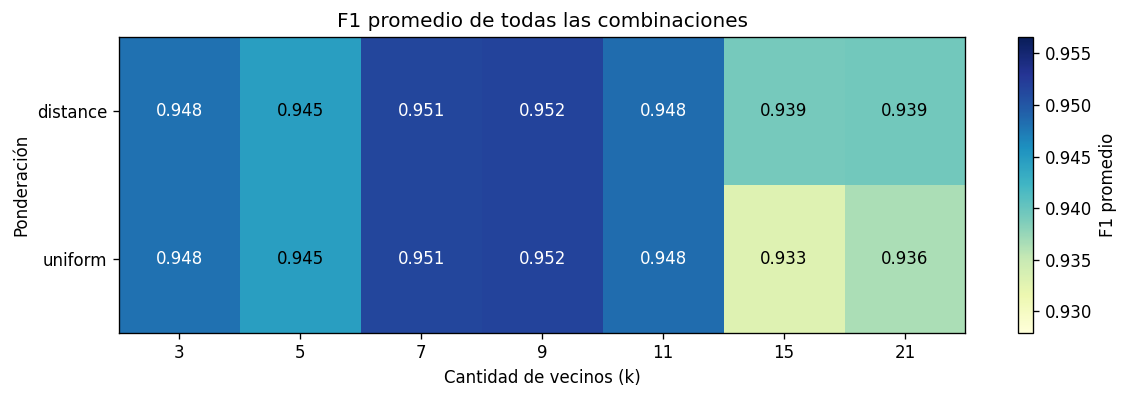

In [13]:
matriz_grid = resultados_grid.pivot(
    index="param_modelo__weights",
    columns="param_modelo__n_neighbors",
    values="mean_test_score",
)

fig, ax = plt.subplots(figsize=(10, 3.4))
imagen = ax.imshow(
    matriz_grid.values,
    cmap="YlGnBu",
    vmin=matriz_grid.values.min() - 0.005,
    vmax=matriz_grid.values.max() + 0.005,
    aspect="auto",
)

ax.set_xticks(range(len(matriz_grid.columns)))
ax.set_xticklabels(matriz_grid.columns.astype(int))
ax.set_yticks(range(len(matriz_grid.index)))
ax.set_yticklabels(matriz_grid.index)
ax.set_xlabel("Cantidad de vecinos (k)")
ax.set_ylabel("Ponderación")
ax.set_title("F1 promedio de todas las combinaciones")

for fila, columna in itertools.product(
    range(matriz_grid.shape[0]),
    range(matriz_grid.shape[1]),
):
    valor = matriz_grid.iloc[fila, columna]
    ax.text(
        columna,
        fila,
        f"{valor:.3f}",
        ha="center",
        va="center",
        color=(
            "white"
            if valor > np.mean(matriz_grid.values)
            else "black"
        ),
    )

fig.colorbar(imagen, ax=ax, label="F1 promedio")
plt.tight_layout()
plt.show()


Las dos configuraciones con `k = 9` empatan en el mayor F1 promedio: una usa pesos uniformes y la otra pondera por distancia. Ante el empate, `GridSearchCV` conserva la primera según el orden de la grilla y por eso `best_params_` muestra pesos uniformes.

`best_score_` representa el F1 promedio de validación cruzada, no el resultado final en test.

La tabla completa permite advertir que varias configuraciones quedan muy próximas. `GridSearchCV` ordena los números, pero no convierte una diferencia mínima en una superioridad segura.


## 7. Explorar un espacio mayor con RandomizedSearchCV

Ahora agregaremos un tercer hiperparámetro:

- `p = 1`: distancia Manhattan;
- `p = 2`: distancia euclidiana.

El espacio completo tendrá veinte valores de `k`, dos ponderaciones y dos formas de medir la distancia. En vez de probar todas las combinaciones, `RandomizedSearchCV` seleccionará solo doce.


In [14]:
param_distributions = {
    "modelo__n_neighbors": list(range(1, 40, 2)),
    "modelo__weights": ["uniform", "distance"],
    "modelo__p": [1, 2],
}

total_combinaciones_random = np.prod([
    len(valores) for valores in param_distributions.values()
])
numero_pruebas_random = 12

pd.DataFrame({
    "combinaciones_posibles": [total_combinaciones_random],
    "combinaciones_evaluadas": [numero_pruebas_random],
    "folds": [cv.get_n_splits()],
    "entrenamientos_cv": [
        numero_pruebas_random * cv.get_n_splits()
    ],
})


,combinaciones_posibles,combinaciones_evaluadas,folds,entrenamientos_cv
0,80,12,5,60


In [15]:
busqueda_aleatoria = RandomizedSearchCV(
    estimator=pipeline_busqueda,
    param_distributions=param_distributions,
    n_iter=numero_pruebas_random,
    cv=cv,
    scoring="f1",
    random_state=42,
    return_train_score=True,
)

busqueda_aleatoria.fit(X_desarrollo, y_desarrollo)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modelo__n_neighbors': [1, 3, ...], 'modelo__p': [1, 2], 'modelo__weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` d

In [16]:
pd.DataFrame({
    "mejores_hiperparametros": [
        str(busqueda_aleatoria.best_params_)
    ],
    "mejor_F1_promedio_cv": [
        busqueda_aleatoria.best_score_
    ],
}).round(4)


,mejores_hiperparametros,mejor_F1_promedio_cv
0,"{'modelo__weights': 'uniform', 'modelo__p': 1,...",0.9529


In [17]:
resultados_aleatorios = pd.DataFrame(
    busqueda_aleatoria.cv_results_
)

columnas_random = [
    "param_modelo__n_neighbors",
    "param_modelo__weights",
    "param_modelo__p",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]

tabla_aleatoria = (
    resultados_aleatorios[columnas_random]
    .copy()
    .sort_values("rank_test_score")
)

tabla_aleatoria.columns = [
    "k",
    "weights",
    "p",
    "F1_train_promedio",
    "F1_validacion_promedio",
    "desviacion_validacion",
    "posicion",
]

tabla_aleatoria.head(8).round(4)


,k,weights,p,F1_train_promedio,F1_validacion_promedio,desviacion_validacion,posicion
1,1,uniform,1,1.0000,0.9529,0.0227,1
8,3,uniform,1,0.9768,0.9521,0.0363,2
4,9,uniform,2,0.9592,0.9516,0.0303,3
2,11,uniform,2,0.9545,0.9483,0.0308,4
9,7,uniform,1,0.9512,0.9482,0.0380,5
6,5,uniform,2,0.9631,0.9446,0.0454,6
11,17,distance,1,1.0000,0.9419,0.0201,7
10,25,distance,1,1.0000,0.9414,0.0266,8


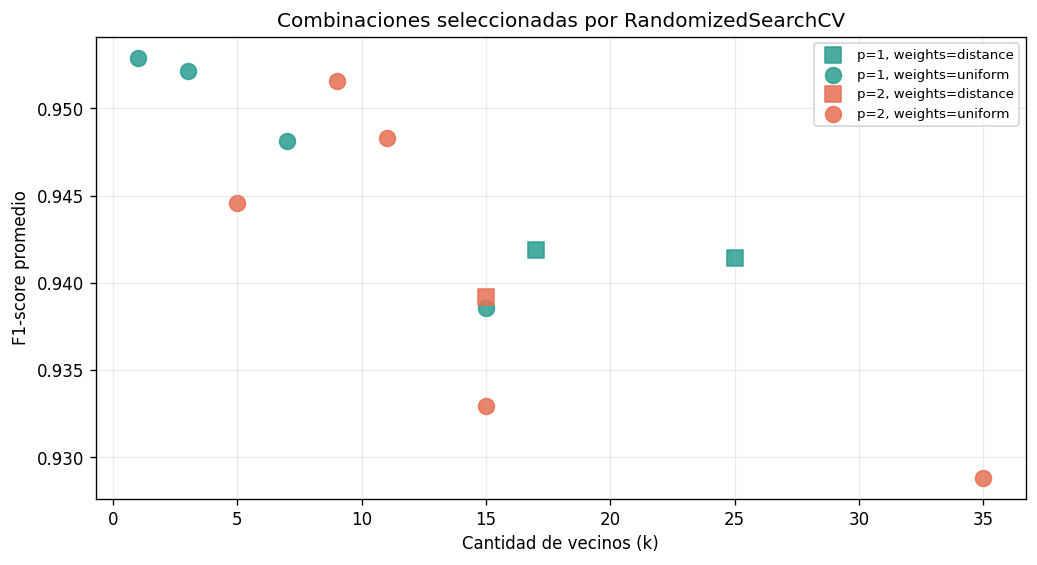

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

colores_p = {1: "#2A9D8F", 2: "#E76F51"}
marcadores_weights = {"uniform": "o", "distance": "s"}

for (p, weights), grupo in tabla_aleatoria.groupby(
    ["p", "weights"]
):
    ax.scatter(
        grupo["k"],
        grupo["F1_validacion_promedio"],
        s=90,
        color=colores_p[p],
        marker=marcadores_weights[weights],
        label=f"p={p}, weights={weights}",
        alpha=0.85,
    )

ax.set_xlabel("Cantidad de vecinos (k)")
ax.set_ylabel("F1-score promedio")
ax.set_title("Combinaciones seleccionadas por RandomizedSearchCV")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.show()


La búsqueda aleatoria encontró como mejor resultado `k = 1`, pesos uniformes y distancia Manhattan. Sin embargo, esta configuración alcanza F1 igual a `1` en entrenamiento y supera a la mejor grilla por una diferencia muy pequeña en validación.

Además, `RandomizedSearchCV` no probó las ochenta combinaciones: solo conoce las doce seleccionadas mediante `random_state=42`. Otra semilla o una cantidad diferente de iteraciones podría producir otro resultado.


## 8. Comparar las búsquedas y aplicar criterio

Reuniremos el mejor resultado de cada estrategia. También calcularemos la brecha entre el desempeño de entrenamiento y el de validación.


In [19]:
indice_grid = busqueda_grid.best_index_
indice_random = busqueda_aleatoria.best_index_

comparacion_busquedas = pd.DataFrame({
    "busqueda": ["GridSearchCV", "RandomizedSearchCV"],
    "combinaciones_evaluadas": [
        cantidad_combinaciones_grid,
        numero_pruebas_random,
    ],
    "entrenamientos_cv": [
        cantidad_entrenamientos_grid,
        numero_pruebas_random * cv.get_n_splits(),
    ],
    "F1_train_promedio": [
        resultados_grid.loc[indice_grid, "mean_train_score"],
        resultados_aleatorios.loc[
            indice_random,
            "mean_train_score",
        ],
    ],
    "F1_validacion_promedio": [
        busqueda_grid.best_score_,
        busqueda_aleatoria.best_score_,
    ],
})

comparacion_busquedas["brecha_train_validacion"] = (
    comparacion_busquedas["F1_train_promedio"]
    - comparacion_busquedas["F1_validacion_promedio"]
)

comparacion_busquedas.round(4)


,busqueda,combinaciones_evaluadas,entrenamientos_cv,F1_train_promedio,F1_validacion_promedio,brecha_train_validacion
0,GridSearchCV,14,70,0.9592,0.9516,0.0076
1,RandomizedSearchCV,12,60,1.0000,0.9529,0.0471


La búsqueda aleatoria obtiene un F1 promedio apenas mayor, pero su mejor configuración presenta una brecha mucho más grande entre entrenamiento y validación. La diferencia entre ambas búsquedas es de alrededor de una milésima.

Para este recorrido elegiremos una de las configuraciones empatadas de la grilla (`k = 9`, pesos uniformes y distancia euclidiana). No afirmamos que sea universalmente superior: preferimos una alternativa de complejidad moderada, con una brecha pequeña y un desempeño de validación prácticamente equivalente.

Este ejemplo muestra por qué el valor numérico más alto no siempre debe decidir por sí solo.


## 9. Comprobar que la métrica cambia la elección

Hasta ahora optimizamos F1-score. Repetiremos la misma grilla usando recall. El test seguirá reservado: ambas búsquedas se realizarán únicamente sobre el conjunto de desarrollo.


In [20]:
busqueda_recall = GridSearchCV(
    estimator=pipeline_busqueda,
    param_grid=param_grid,
    cv=cv,
    scoring="recall",
)

busqueda_recall.fit(X_desarrollo, y_desarrollo)

pd.DataFrame({
    "metrica_optimizada": ["F1-score", "Recall"],
    "mejores_hiperparametros": [
        str(busqueda_grid.best_params_),
        str(busqueda_recall.best_params_),
    ],
    "mejor_promedio_cv": [
        busqueda_grid.best_score_,
        busqueda_recall.best_score_,
    ],
}).round(4)


,metrica_optimizada,mejores_hiperparametros,mejor_promedio_cv
0,F1-score,"{'modelo__n_neighbors': 9, 'modelo__weights': ...",0.9516
1,Recall,"{'modelo__n_neighbors': 7, 'modelo__weights': ...",0.9235


Al optimizar F1-score, la grilla elige `k = 9`. Al priorizar recall, elige `k = 7`. No debemos comparar directamente los valores de la última columna porque pertenecen a métricas diferentes.

La conclusión importante es metodológica: **la mejor configuración depende de qué entendemos por “mejor”**. La métrica debe elegirse según el problema antes de iniciar la búsqueda.


## 10. Evaluar una vez sobre el conjunto de prueba

Todas las decisiones anteriores se tomaron mediante validación cruzada dentro del conjunto de desarrollo. Ahora usaremos el mejor estimador de la grilla de F1 y consultaremos el test final por primera vez.

Por defecto, `GridSearchCV` ya volvió a entrenar `best_estimator_` con todo el conjunto que recibió en `fit()`.


In [21]:
modelo_final = busqueda_grid.best_estimator_
pred_test_final = modelo_final.predict(X_test_final)

metricas_finales = pd.DataFrame({
    "metrica": [
        "F1 promedio en validación cruzada",
        "Accuracy en test",
        "Precision en test",
        "Recall en test",
        "F1-score en test",
    ],
    "valor": [
        busqueda_grid.best_score_,
        accuracy_score(y_test_final, pred_test_final),
        precision_score(y_test_final, pred_test_final),
        recall_score(y_test_final, pred_test_final),
        f1_score(y_test_final, pred_test_final),
    ],
})

metricas_finales.round(4)


,metrica,valor
0,F1 promedio en validación cruzada,0.9516
1,Accuracy en test,0.9474
2,Precision en test,0.9737
3,Recall en test,0.8810
4,F1-score en test,0.9250


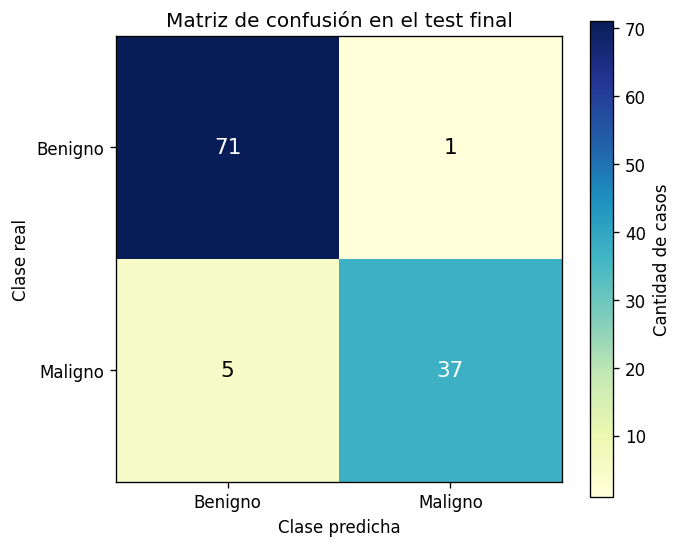

In [22]:
matriz_final = confusion_matrix(
    y_test_final,
    pred_test_final,
)

fig, ax = plt.subplots(figsize=(5.8, 4.8))
imagen = ax.imshow(matriz_final, cmap="YlGnBu")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Benigno", "Maligno"])
ax.set_yticklabels(["Benigno", "Maligno"])
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_title("Matriz de confusión en el test final")

for fila, columna in itertools.product(range(2), range(2)):
    valor = matriz_final[fila, columna]
    ax.text(
        columna,
        fila,
        valor,
        ha="center",
        va="center",
        fontsize=13,
        color=(
            "white"
            if valor > matriz_final.max() / 2
            else "black"
        ),
    )

fig.colorbar(imagen, ax=ax, label="Cantidad de casos")
plt.tight_layout()
plt.show()


El modelo obtiene un F1-score de `0,925` en el test final. La matriz muestra 71 casos benignos y 37 malignos clasificados correctamente, junto con un falso positivo y cinco falsos negativos.

El resultado final es menor que el promedio de validación cruzada. Esto no invalida la búsqueda: confirma que las métricas son estimaciones sujetas a variación. El test aporta una medición independiente, no una garantía sobre todos los datos futuros.

No deberíamos volver ahora a la búsqueda, modificar la grilla basándonos en este resultado y consultar otra vez el mismo test como si continuara siendo nuevo.


## 11. Actividad breve

La siguiente celda permite construir una grilla pequeña. Modificá sus tres primeras variables y observá cómo cambian la cantidad de entrenamientos y la configuración elegida. La actividad continúa usando solo el conjunto de desarrollo.


In [23]:
valores_k_actividad = [3, 5, 7, 9, 11]
pesos_actividad = ["uniform", "distance"]
metrica_actividad = "f1"

grilla_actividad = {
    "modelo__n_neighbors": valores_k_actividad,
    "modelo__weights": pesos_actividad,
}

busqueda_actividad = GridSearchCV(
    estimator=pipeline_busqueda,
    param_grid=grilla_actividad,
    cv=cv,
    scoring=metrica_actividad,
)

busqueda_actividad.fit(X_desarrollo, y_desarrollo)

pd.DataFrame({
    "combinaciones": [
        len(valores_k_actividad) * len(pesos_actividad)
    ],
    "entrenamientos_cv": [
        len(valores_k_actividad)
        * len(pesos_actividad)
        * cv.get_n_splits()
    ],
    "mejores_hiperparametros": [
        str(busqueda_actividad.best_params_)
    ],
    "mejor_promedio_cv": [
        busqueda_actividad.best_score_
    ],
}).round(4)


,combinaciones,entrenamientos_cv,mejores_hiperparametros,mejor_promedio_cv
0,10,50,"{'modelo__n_neighbors': 9, 'modelo__weights': ...",0.9516


Podés explorar la actividad de esta manera:

1. quitá o agregá valores de `k` y calculá cómo cambia el costo;
2. usá primero `f1` y luego `recall`;
3. compará la configuración elegida, pero no consultes el test final;
4. explicá si una mejora muy pequeña justifica ampliar la grilla.


## 12. Síntesis

En este cuaderno:

- distinguimos parámetros aprendidos de hiperparámetros;
- relacionamos `k` con la flexibilidad de KNN;
- realizamos una búsqueda manual con validación cruzada;
- ajustamos un pipeline completo para evitar fuga durante el escalado;
- usamos `GridSearchCV` para probar todas las combinaciones de una grilla;
- interpretamos `best_params_`, `best_score_`, `best_estimator_` y `cv_results_`;
- usamos `RandomizedSearchCV` para explorar un espacio mayor con un costo limitado;
- calculamos combinaciones y entrenamientos;
- comprobamos que distintas métricas pueden elegir configuraciones diferentes;
- aplicamos criterio ante resultados casi empatados;
- reservamos el test para una única evaluación final.

El ajuste de hiperparámetros no consiste en perseguir indefinidamente el número más alto. Su objetivo es encontrar una configuración razonable, estable y coherente con el problema sin engañar la evaluación.


## Para pensar

1. ¿Por qué `modelo__n_neighbors` lleva un doble guion bajo dentro de la grilla?
2. ¿Qué información perderíamos si observáramos solo el promedio y no la variabilidad entre folds?
3. ¿Cuándo preferirías `RandomizedSearchCV` en lugar de `GridSearchCV`?
4. ¿Por qué F1-score y recall pueden elegir hiperparámetros diferentes?
5. ¿Qué ocurre con la honestidad de la evaluación si usamos repetidamente el test para modificar la búsqueda?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
